# Monte Carlo Schedule Risk Simulator V1

Step 1 — Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 2 — Load same Primavera export / risk report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Primavera Risk Dashboard V1.xlsx to Primavera Risk Dashboard V1 (5).xlsx


In [ ]:
activity_risk_report = pd.read_excel(
    "Primavera Risk Dashboard V1.xlsx"
)

print(activity_risk_report.shape)
activity_risk_report.head()

(4217, 15)


,task_code,task_name,wbs_name,total_float_days,remaining_days,successor_count,critical_density,float_risk,dependency_risk,duration_risk,package_risk,gateway_risk,activity_risk_score,risk_category,risk_reason
0,H0000,Start Date,Project Milestone,0.0,1.0,32,100.000000,100,100,30,100,60,85.5,Critical,Low/zero float + High successor impact + Locat...
1,HCESCA000,s/c approval: MEP subcontractor,Approval,0.0,14.0,12,50.000000,100,80,30,100,100,84.5,Critical,Low/zero float + High successor impact + Locat...
2,HESDSSS0000,SD submission: Steel Strucutre shopdrawings,Steel Strucuture,0.0,100.0,6,100.000000,100,50,100,100,20,79.5,High,Low/zero float + Long duration exposure + Loca...
3,HESDASS0000,SD approval: Steel Strucutre shopdrawings,Steel Strucuture,0.0,100.0,1,100.000000,100,20,100,100,75,77.5,High,Low/zero float + Long duration exposure + Loca...
4,HEPSAME1160,Diffusers,MEP Materials,0.0,240.0,6,13.043478,100,50,100,50,20,74.5,High,Low/zero float + Long duration exposure


In [ ]:
activity_risk_report.columns.tolist()

['task_code',
 'task_name',
 'wbs_name',
 'total_float_days',
 'remaining_days',
 'successor_count',
 'critical_density',
 'float_risk',
 'dependency_risk',
 'duration_risk',
 'package_risk',
 'gateway_risk',
 'activity_risk_score',
 'risk_category',
 'risk_reason']

In [ ]:
print("Activities:", len(activity_risk_report))

print("\nColumns:")
for col in activity_risk_report.columns:
    print(col)

Activities: 4217

Columns:
task_code
task_name
wbs_name
total_float_days
remaining_days
successor_count
critical_density
float_risk
dependency_risk
duration_risk
package_risk
gateway_risk
activity_risk_score
risk_category
risk_reason


Step 1 — Prepare duration data

In [ ]:
mc_data = activity_risk_report.copy()

mc_data = mc_data[
    mc_data["remaining_days"].notna()
]

mc_data = mc_data[
    mc_data["remaining_days"] > 0
]

print("Activities used in simulation:", len(mc_data))

mc_data[
    ["task_code", "task_name", "wbs_name", "remaining_days", "total_float_days"]
].head()

Activities used in simulation: 3954


,task_code,task_name,wbs_name,remaining_days,total_float_days
0,H0000,Start Date,Project Milestone,1.0,0.0
1,HCESCA000,s/c approval: MEP subcontractor,Approval,14.0,0.0
2,HESDSSS0000,SD submission: Steel Strucutre shopdrawings,Steel Strucuture,100.0,0.0
3,HESDASS0000,SD approval: Steel Strucutre shopdrawings,Steel Strucuture,100.0,0.0
4,HEPSAME1160,Diffusers,MEP Materials,240.0,0.0


In [ ]:
mc_data["optimistic_days"] = mc_data["remaining_days"] * 0.80
mc_data["most_likely_days"] = mc_data["remaining_days"]
mc_data["pessimistic_days"] = mc_data["remaining_days"] * 1.30

mc_data[
    [
        "task_code",
        "task_name",
        "remaining_days",
        "optimistic_days",
        "most_likely_days",
        "pessimistic_days"
    ]
].head()

,task_code,task_name,remaining_days,optimistic_days,most_likely_days,pessimistic_days
0,H0000,Start Date,1.0,0.8,1.0,1.3
1,HCESCA000,s/c approval: MEP subcontractor,14.0,11.2,14.0,18.2
2,HESDSSS0000,SD submission: Steel Strucutre shopdrawings,100.0,80.0,100.0,130.0
3,HESDASS0000,SD approval: Steel Strucutre shopdrawings,100.0,80.0,100.0,130.0
4,HEPSAME1160,Diffusers,240.0,192.0,240.0,312.0


In [ ]:
mc_data["optimistic_days"] = mc_data["remaining_days"] * 0.80
mc_data["most_likely_days"] = mc_data["remaining_days"]
mc_data["pessimistic_days"] = mc_data["remaining_days"] * 1.30

mc_data[
    [
        "task_code",
        "task_name",
        "remaining_days",
        "optimistic_days",
        "most_likely_days",
        "pessimistic_days"
    ]
].head()

,task_code,task_name,remaining_days,optimistic_days,most_likely_days,pessimistic_days
0,H0000,Start Date,1.0,0.8,1.0,1.3
1,HCESCA000,s/c approval: MEP subcontractor,14.0,11.2,14.0,18.2
2,HESDSSS0000,SD submission: Steel Strucutre shopdrawings,100.0,80.0,100.0,130.0
3,HESDASS0000,SD approval: Steel Strucutre shopdrawings,100.0,80.0,100.0,130.0
4,HEPSAME1160,Diffusers,240.0,192.0,240.0,312.0


In [ ]:
n_simulations = 1000

simulation_results = []

for i in range(n_simulations):

    simulated_durations = np.random.triangular(
        left=mc_data["optimistic_days"],
        mode=mc_data["most_likely_days"],
        right=mc_data["pessimistic_days"]
    )

    simulated_project_duration = simulated_durations.max()

    simulation_results.append(simulated_project_duration)

simulation_results = np.array(simulation_results)

print("Simulations completed:", len(simulation_results))
print("Minimum simulated duration:", simulation_results.min())
print("Average simulated duration:", simulation_results.mean())
print("Maximum simulated duration:", simulation_results.max())

Simulations completed: 1000
Minimum simulated duration: 333.44524871406645
Average simulated duration: 382.03119722582966
Maximum simulated duration: 426.68825378782935


In [ ]:
p50 = np.percentile(simulation_results, 50)
p80 = np.percentile(simulation_results, 80)
p90 = np.percentile(simulation_results, 90)

print("P50 Duration:", round(p50, 1), "days")
print("P80 Duration:", round(p80, 1), "days")
print("P90 Duration:", round(p90, 1), "days")

P50 Duration: 380.7 days
P80 Duration: 399.9 days
P90 Duration: 410.3 days


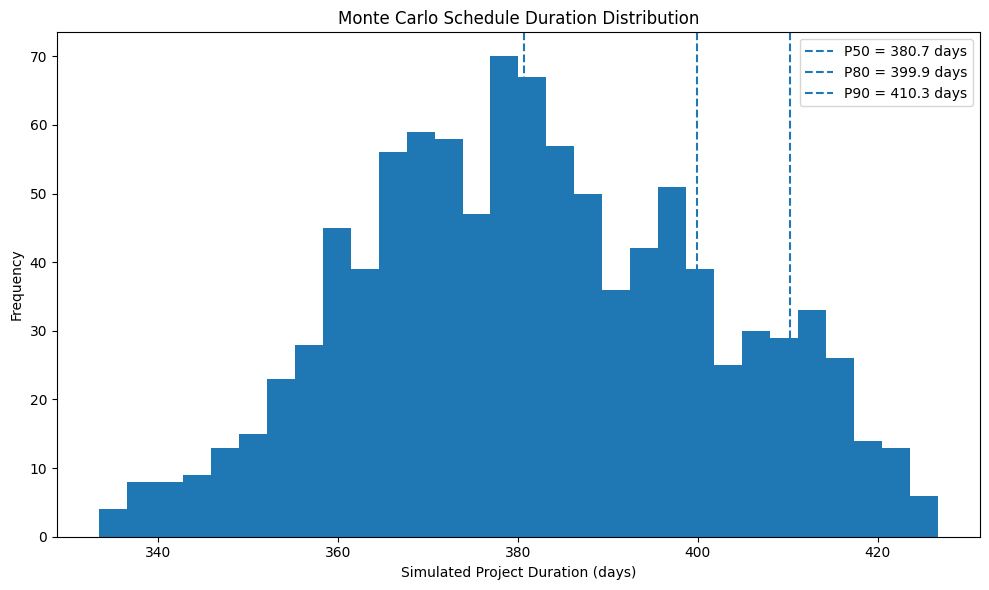

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    simulation_results,
    bins=30
)

plt.axvline(p50, linestyle="--", label=f"P50 = {p50:.1f} days")
plt.axvline(p80, linestyle="--", label=f"P80 = {p80:.1f} days")
plt.axvline(p90, linestyle="--", label=f"P90 = {p90:.1f} days")

plt.title("Monte Carlo Schedule Duration Distribution")
plt.xlabel("Simulated Project Duration (days)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Step 1 — Calculate Baseline Duration

In [ ]:
baseline_duration = mc_data["remaining_days"].max()

print("Baseline Duration:", baseline_duration)

Baseline Duration: 330.0


Step 2 — Probability of Meeting Baseline

In [ ]:
probability_meeting_baseline = (
    np.sum(simulation_results <= baseline_duration)
    / len(simulation_results)
) * 100

print(
    f"Probability of meeting baseline: {probability_meeting_baseline:.1f}%"
)

Probability of meeting baseline: 0.0%


Step 3 — Schedule Uncertainty

In [ ]:
schedule_uncertainty = p90 - p50

print(
    f"Schedule Uncertainty: {schedule_uncertainty:.1f} days"
)

Schedule Uncertainty: 29.6 days


Step 4 — Executive Summary

In [ ]:
print("\n")
print("===== MONTE CARLO SCHEDULE RISK SUMMARY =====")

print(f"Activities Analyzed: {len(mc_data)}")

print(f"Baseline Duration: {baseline_duration:.1f} days")

print(f"P50 Duration: {p50:.1f} days")

print(f"P80 Duration: {p80:.1f} days")

print(f"P90 Duration: {p90:.1f} days")

print(
    f"Probability of Meeting Baseline: "
    f"{probability_meeting_baseline:.1f}%"
)

print(
    f"Schedule Uncertainty: "
    f"{schedule_uncertainty:.1f} days"
)



===== MONTE CARLO SCHEDULE RISK SUMMARY =====
Activities Analyzed: 3954
Baseline Duration: 330.0 days
P50 Duration: 380.7 days
P80 Duration: 399.9 days
P90 Duration: 410.3 days
Probability of Meeting Baseline: 0.0%
Schedule Uncertainty: 29.6 days


Step 5 — Export Results

Step 5 — Export Results

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Baseline Duration",
        "P50 Duration",
        "P80 Duration",
        "P90 Duration",
        "Probability of Meeting Baseline (%)",
        "Schedule Uncertainty"
    ],
    "Value": [
        baseline_duration,
        p50,
        p80,
        p90,
        probability_meeting_baseline,
        schedule_uncertainty
    ]
})

summary.to_excel(
    "Monte_Carlo_Summary.xlsx",
    index=False
)

print("Summary exported successfully.")

Summary exported successfully.
